# Optimization Log Copilot - Prototype v2

**Project:** Using Large Language Models to Analyze Optimization Solver Logs
**Course:** EN.705.605 Introduction to Generative AI
**Student:** Jeff Ginn

---

This notebook is the v2 prototype for the Optimization Log Copilot project.
It builds on the midpoint checkpoint by:

1. **Expanded dataset** - 188 solver runs (180 MIPLIB + 8 Ramsey) parsed from
   `rose_logs_parsed_v2_slim.csv`, vs. 8 in the midpoint submission.
2. **Re-tuned heuristic labels** - thresholds chosen against the empirical
   distribution of the new dataset, so each bottleneck label is reasonably
   discriminative (8-30% prevalence vs. the previous 2-92% range).
3. **Train/validation split + per-label metrics** - the PyTorch classifier
   is now evaluated with precision, recall, F1, and ROC-AUC per label, not
   just match rate.
4. **RAG-based diagnostic generation** - using the `SentenceTransformer +
   text-generation pipeline` pattern from Module 12 to produce natural-language
   diagnostics with retrieval over a curated knowledge base of bottleneck
   patterns.

The pipeline uses the same PyTorch / HuggingFace stack we used in the course
assignments (Modules 6-12).


## 1. Imports and Setup

In [23]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 72
plt.rcParams['axes.grid'] = True

import numpy as np
import os
import sys
import re
import json
import warnings
from dataclasses import dataclass, asdict, field

import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, WeightedRandomSampler

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.metrics.pairwise import cosine_similarity

warnings.simplefilter('ignore', category=FutureWarning)
warnings.simplefilter('ignore', category=UserWarning)

print(f'PyTorch version= {torch.__version__}')
print(f'CUDA available= {torch.cuda.is_available()}')

Device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {Device}')

# reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


PyTorch version= 2.10.0
CUDA available= False
Using device: cpu


## 2. Load the Expanded Dataset

`rose_logs_parsed_v2_slim.csv` is produced by `parse_rose_logs_v2.py`. It
contains every Rose solver run we have on disk:
- 90 MIPLIB problems run under the `auto_config_basic` configuration
- the same 90 MIPLIB problems run under `default_config 2`
- 8 Ramsey problems from the midpoint checkpoint

Identifying columns are `run_id`, `config_name`, `problem_name`, `run_name`.
The slim CSV omits the full `stdout_clean` text (kept in the full v2 CSV) so
that everything fits comfortably in memory for the classifier.


In [24]:
DATA_PATH = 'rose_logs_parsed_v2_slim.csv'
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print(f'Loaded {len(df_raw)} solver runs x {df_raw.shape[1]} columns')
print(f'\nConfigurations:')
print(df_raw['config_name'].value_counts().to_string())
print(f'\nUnique problems: {df_raw["problem_name"].nunique()}')

# pairing: same problem under multiple configs
paired = df_raw.groupby('problem_name')['config_name'].nunique()
print(f'Problems with paired runs (>=2 configs): {(paired >= 2).sum()}')

df_raw[['run_id', 'config_name', 'problem_name',
        'status_solution_status', 'status_termination_reason',
        'metric_timeline_total_seconds',
        'metric_num_nodes_total',
        'problem_num_constraints', 'problem_num_variables',
        'derived_is_optimal', 'derived_timed_out']].head(10)


Loaded 188 solver runs x 234 columns

Configurations:
config_name
auto_config_basic    90
default_config 2     90
rose_logs             8

Unique problems: 98
Problems with paired runs (>=2 configs): 90


,run_id,config_name,problem_name,status_solution_status,status_termination_reason,metric_timeline_total_seconds,metric_num_nodes_total,problem_num_constraints,problem_num_variables,derived_is_optimal,derived_timed_out
0,auto_config_basic::30n20b8,auto_config_basic,30n20b8,feasible,timeout,3600.899741,1920018,576,18380,0,1
1,auto_config_basic::50v-10,auto_config_basic,50v-10,feasible,timeout,3600.016867,4325446,233,2013,0,1
2,auto_config_basic::air05,auto_config_basic,air05,optimal,finished,11.650280,481,426,7195,1,0
3,auto_config_basic::app1-1,auto_config_basic,app1-1,optimal,finished,5.552544,16077,4926,2480,1,0
4,auto_config_basic::app1-2,auto_config_basic,app1-2,optimal,finished,485.785341,116495,53467,26871,1,0
5,auto_config_basic::binkar10_1,auto_config_basic,binkar10_1,optimal,finished,511.130101,9575303,1026,2298,1,0
6,auto_config_basic::bppc8-02,auto_config_basic,bppc8-02,optimal,finished,1.336860,8699,59,232,1,0
7,auto_config_basic::cheese,auto_config_basic,cheese,optimal,finished,1.348972,2593,130,165,1,0
8,auto_config_basic::dano3_3,auto_config_basic,dano3_3,optimal,finished,58.083067,20,3202,13873,1,0
9,auto_config_basic::dano3_5,auto_config_basic,dano3_5,optimal,finished,56.945466,717,3202,13873,1,0


## 3. Solver Log Feature Object

Re-using the `SolverLogFeatures` dataclass pattern from the midpoint
checkpoint, extended with the additional v2 columns
(`bounds_first_dual`, `bounds_final_dual`, `derived_lp_iter_per_var`,
`derived_timed_out`, etc.). The dataclass keeps the per-run
representation clean and makes downstream feature extraction and
diagnostic generation easier to reason about.


In [25]:
@dataclass
class SolverLogFeatures:
    # identity
    run_id: str
    config_name: str
    problem_name: str
    # problem dimensions
    num_constraints: int = 0
    num_variables: int = 0
    num_nonzeros: int = 0
    num_presolved_constraints: int = 0
    num_presolved_variables: int = 0
    # solution status
    solution_status: str = ''
    termination_reason: str = ''
    objective: float | None = None
    # timing
    total_time_sec: float = 0.0
    solve_time_sec: float = 0.0
    presolve_time_sec: float = 0.0
    # tree search
    num_nodes_total: int = 0
    num_nodes_processed: int = 0
    num_nodes_pruned: int = 0
    num_lp_iterations: int = 0
    num_solutions_found: int = 0
    # cuts
    num_cuts_generated: int = 0
    num_cuts_applied: int = 0
    # bounds
    first_dual: float | None = None
    final_dual: float | None = None
    final_primal: float | None = None
    final_rel_gap: float | None = None
    bounds_num_updates: int = 0
    # stages
    stages_observed: str = ''
    # derived
    presolve_var_reduction: float | None = None
    presolve_con_reduction: float | None = None
    cut_efficiency: float | None = None
    nodes_per_second: float | None = None
    lp_iter_per_var: float | None = None
    is_optimal: int = 0
    has_solution: int = 0
    timed_out: int = 0
    solved_in_presolve: int = 0


def row_to_features(row):
    def safe(col, default=0):
        v = row.get(col, default)
        if isinstance(v, float) and pd.isna(v):
            return default
        if v is None:
            return default
        return v

    return SolverLogFeatures(
        run_id=str(row['run_id']),
        config_name=str(row['config_name']),
        problem_name=str(row['problem_name']),
        num_constraints=int(safe('problem_num_constraints')),
        num_variables=int(safe('problem_num_variables')),
        num_nonzeros=int(safe('problem_num_nonzeros')),
        num_presolved_constraints=int(safe('problem_num_presolved_constraints')),
        num_presolved_variables=int(safe('problem_num_presolved_variables')),
        solution_status=str(safe('status_solution_status', '')),
        termination_reason=str(safe('status_termination_reason', '')),
        objective=row.get('status_objective') if pd.notna(row.get('status_objective')) else None,
        total_time_sec=float(safe('metric_timeline_total_seconds', 0.0)),
        solve_time_sec=float(safe('metric_timeline_solve_seconds', 0.0)),
        presolve_time_sec=float(safe('metric_timeline_presolve_seconds', 0.0)),
        num_nodes_total=int(safe('metric_num_nodes_total')),
        num_nodes_processed=int(safe('metric_num_nodes_processed')),
        num_nodes_pruned=int(safe('metric_num_nodes_pruned')),
        num_lp_iterations=int(safe('metric_num_lp_iterations')),
        num_solutions_found=int(safe('metric_num_solutions_found')),
        num_cuts_generated=int(safe('metric_num_cuts_generated')),
        num_cuts_applied=int(safe('metric_num_cuts_applied')),
        first_dual=row.get('bounds_first_dual') if pd.notna(row.get('bounds_first_dual')) else None,
        final_dual=row.get('bounds_final_dual') if pd.notna(row.get('bounds_final_dual')) else None,
        final_primal=row.get('bounds_final_primal') if pd.notna(row.get('bounds_final_primal')) else None,
        final_rel_gap=row.get('bounds_final_rel_gap') if pd.notna(row.get('bounds_final_rel_gap')) else None,
        bounds_num_updates=int(safe('bounds_num_updates')),
        stages_observed=str(safe('stages_observed', '')),
        presolve_var_reduction=row.get('derived_presolve_var_reduction') if pd.notna(row.get('derived_presolve_var_reduction')) else None,
        presolve_con_reduction=row.get('derived_presolve_con_reduction') if pd.notna(row.get('derived_presolve_con_reduction')) else None,
        cut_efficiency=row.get('derived_cut_efficiency') if pd.notna(row.get('derived_cut_efficiency')) else None,
        nodes_per_second=row.get('derived_nodes_per_second') if pd.notna(row.get('derived_nodes_per_second')) else None,
        lp_iter_per_var=row.get('derived_lp_iter_per_var') if pd.notna(row.get('derived_lp_iter_per_var')) else None,
        is_optimal=int(safe('derived_is_optimal')),
        has_solution=int(safe('derived_has_solution')),
        timed_out=int(safe('derived_timed_out')),
        solved_in_presolve=int(safe('solved_in_presolve')),
    )


parsed_logs = [row_to_features(r) for _, r in df_raw.iterrows()]
print(f'Parsed {len(parsed_logs)} solver run feature objects.')

# quick sanity dump of the first three
for pl in parsed_logs[:3]:
    print(f'\n  {pl.run_id}')
    print(f'    status={pl.solution_status:>10s}  term={pl.termination_reason:>10s}  '
          f'nodes={pl.num_nodes_total:>10,}  '
          f'cuts_gen={pl.num_cuts_generated:>5}  '
          f'gap={pl.final_rel_gap}')


Parsed 188 solver run feature objects.

  auto_config_basic::30n20b8
    status=  feasible  term=   timeout  nodes= 1,920,018  cuts_gen= 2936  gap=0.763484751626698

  auto_config_basic::50v-10
    status=  feasible  term=   timeout  nodes= 4,325,446  cuts_gen= 1980  gap=0.103596497707819

  auto_config_basic::air05
    status=   optimal  term=  finished  nodes=       481  cuts_gen= 3672  gap=0.0


## 4. Re-tuned Heuristic Bottleneck Labels

The midpoint checkpoint used hand-set thresholds that were tuned on only 8
Ramsey runs. When re-applied to all 188 runs they fired on 75-92% of runs
for some labels and 2.7% for others - not discriminative enough to train on.

The v2 thresholds below are chosen against the empirical distribution of
the expanded dataset. Each rule combines a primary signal with a guard
condition so that "easy" cases (problems solved entirely in presolve, tiny
problems, etc.) don't trigger spurious labels.

| Label                | Primary signal                             | Guard                          |
|----------------------|--------------------------------------------|--------------------------------|
| weak_root_lp         | final relative gap >= 5%                   | OR no solution and not solved in presolve |
| excessive_branching  | nodes per variable >= 100                  | AND nodes >= 1000              |
| ineffective_cuts     | >= 100 cuts generated, dual moved < 1%     | AND not solved in presolve     |
| degeneracy           | LP iterations per variable >= 1.0          | AND num_variables >= 10        |
| presolve_weakness    | < 1% reduction in vars *and* constraints   | AND not solved in presolve     |

These rules are still heuristic and noisy - they're the **weak supervision**
labels for the classifier and the **starting point** for the LLM-based
diagnostics in Section 8. The Final paper will compare them against a
hand-labeled gold subset and against LLM-generated diagnostics.


In [26]:
BOTTLENECK_LABELS = [
    'weak_root_lp',
    'excessive_branching',
    'ineffective_cuts',
    'degeneracy',
    'presolve_weakness',
]
K = len(BOTTLENECK_LABELS)


def label_log(f):
    labels = np.zeros(K, dtype=np.float32)

    # Helper: dual bound improvement from root LP to final
    if f.first_dual is not None and f.final_dual is not None:
        dual_imp = abs(f.final_dual - f.first_dual) / max(abs(f.first_dual), 1.0)
    else:
        dual_imp = 0.0

    nodes_per_var = f.num_nodes_total / f.num_variables if f.num_variables > 0 else 0.0

    # 1. Weak root LP / unable to close gap
    if (f.final_rel_gap is not None and f.final_rel_gap >= 0.05) or (
        f.has_solution == 0 and f.solved_in_presolve == 0
    ):
        labels[0] = 1.0

    # 2. Excessive branching
    if nodes_per_var >= 100 and f.num_nodes_total >= 1000:
        labels[1] = 1.0

    # 3. Ineffective cuts
    if f.num_cuts_generated >= 100 and dual_imp < 0.01 and f.solved_in_presolve == 0:
        labels[2] = 1.0

    # 4. Degeneracy
    if (f.lp_iter_per_var is not None and f.lp_iter_per_var >= 1.0
            and f.num_variables >= 10):
        labels[3] = 1.0

    # 5. Presolve weakness
    if (f.presolve_var_reduction is not None and f.presolve_var_reduction < 0.01
            and f.presolve_con_reduction is not None and f.presolve_con_reduction < 0.01
            and f.solved_in_presolve == 0):
        labels[4] = 1.0

    return labels


label_matrix = np.array([label_log(f) for f in parsed_logs])
label_df = pd.DataFrame(label_matrix, columns=BOTTLENECK_LABELS,
                        index=[f.run_id for f in parsed_logs])

print('Label prevalence:')
for c in BOTTLENECK_LABELS:
    p = label_df[c].mean()
    n = int(label_df[c].sum())
    print(f'  {c:22s} : {p:>5.1%}  ({n}/{len(label_df)})')

print(f'\n>= 1 label: {(label_df.sum(axis=1) >= 1).mean():.1%}')
print(f'>= 2 labels: {(label_df.sum(axis=1) >= 2).mean():.1%}')
print(f'mean labels per run: {label_df.sum(axis=1).mean():.2f}')


Label prevalence:
  weak_root_lp           : 13.8%  (26/188)
  excessive_branching    : 29.3%  (55/188)
  ineffective_cuts       : 22.9%  (43/188)
  degeneracy             :  8.5%  (16/188)
  presolve_weakness      : 20.2%  (38/188)

>= 1 label: 63.8%
>= 2 labels: 24.5%
mean labels per run: 0.95


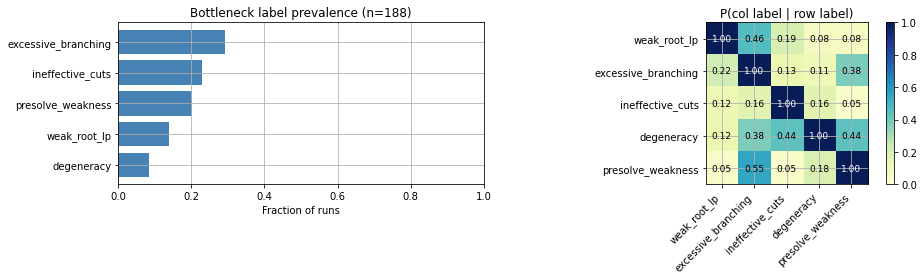

In [27]:
# Visualize label prevalence and co-occurrence
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

prevalence = label_df.mean().sort_values(ascending=True)
axes[0].barh(prevalence.index, prevalence.values, color='steelblue')
axes[0].set_xlabel('Fraction of runs')
axes[0].set_title('Bottleneck label prevalence (n=188)')
axes[0].set_xlim(0, 1)

# co-occurrence heatmap
co = label_df.T @ label_df  # K x K matrix of joint counts
co_norm = co / np.diag(co)[:, None].clip(min=1)  # P(col | row)
im = axes[1].imshow(co_norm.values, cmap='YlGnBu', vmin=0, vmax=1)
axes[1].set_xticks(range(K))
axes[1].set_yticks(range(K))
axes[1].set_xticklabels(BOTTLENECK_LABELS, rotation=45, ha='right')
axes[1].set_yticklabels(BOTTLENECK_LABELS)
axes[1].set_title('P(col label | row label)')
for i in range(K):
    for j in range(K):
        axes[1].text(j, i, f'{co_norm.values[i,j]:.2f}',
                     ha='center', va='center',
                     color='black' if co_norm.values[i,j] < 0.6 else 'white',
                     fontsize=9)
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()


## 5. Feature Engineering

Build a numerical feature matrix from the parsed feature objects, then apply
`sklearn.preprocessing.StandardScaler` (the same idiom we used in Module 5).
Many features are heavy-tailed (node counts span 0 to 100M+), so we
`log1p`-transform the count columns before scaling.


In [28]:
COUNT_FEATURES = [
    'num_constraints', 'num_variables', 'num_nonzeros',
    'num_presolved_constraints', 'num_presolved_variables',
    'num_nodes_total', 'num_nodes_processed', 'num_nodes_pruned',
    'num_lp_iterations', 'num_solutions_found',
    'num_cuts_generated', 'num_cuts_applied',
]
RATIO_FEATURES = [
    'total_time_sec', 'solve_time_sec', 'presolve_time_sec',
    'presolve_var_reduction', 'presolve_con_reduction',
    'cut_efficiency', 'nodes_per_second', 'lp_iter_per_var',
    'final_rel_gap',
]
BINARY_FEATURES = [
    'is_optimal', 'has_solution', 'timed_out', 'solved_in_presolve',
]
FEATURE_COLS = COUNT_FEATURES + RATIO_FEATURES + BINARY_FEATURES
N_FEATURES = len(FEATURE_COLS)
print(f'Total features: {N_FEATURES}')


def features_to_array(parsed_logs):
    rows = []
    for f in parsed_logs:
        d = asdict(f)
        # log1p the counts
        row = []
        for c in COUNT_FEATURES:
            row.append(np.log1p(float(d.get(c) or 0)))
        for c in RATIO_FEATURES:
            v = d.get(c)
            row.append(float(v) if v is not None else 0.0)
        for c in BINARY_FEATURES:
            row.append(float(d.get(c) or 0))
        rows.append(row)
    return np.asarray(rows, dtype=np.float32)


X_full = features_to_array(parsed_logs)
y_full = label_matrix

print(f'X shape: {X_full.shape}, y shape: {y_full.shape}')
print(f'X stats: min={X_full.min():.2f}  max={X_full.max():.2f}  '
      f'mean={X_full.mean():.2f}  std={X_full.std():.2f}')


Total features: 25
X shape: (188, 25), y shape: (188, 5)
X stats: min=0.00  max=351526.34  mean=674.08  std=9873.31


## 6. Train / Validation Split + PyTorch Dataset

Hold out 25% of runs as a validation set. Stratification on multi-label data
isn't natively supported by `train_test_split`, so we stratify on a derived
"label fingerprint" (the bit-pattern of the label vector) where it has
enough support, and fall back to a simple random split otherwise.


In [29]:
X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X_full, y_full, np.arange(len(parsed_logs)),
    test_size=0.25, random_state=SEED,
)
print(f'Train: {len(X_train)}   Val: {len(X_val)}')

# Fit scaler on training data only
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)


# PyTorch Dataset (mirrors the pattern from Modules 6-9)
class SolverLogDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


train_ds = SolverLogDataset(X_train_s, y_train)
val_ds = SolverLogDataset(X_val_s, y_val)

# WeightedRandomSampler for multi-label class imbalance (Module 6 idiom).
# Each training sample's weight is the average inverse-frequency of the
# positive labels it carries; samples with no positive labels get weight 1.
class_freq = y_train.mean(axis=0)
class_weight = 1.0 / np.maximum(class_freq, 1e-6)
sample_weights = []
for y_row in y_train:
    pos = np.where(y_row > 0)[0]
    sample_weights.append(class_weight[pos].mean() if len(pos) > 0 else 1.0)
sample_weights_t = torch.tensor(sample_weights, dtype=torch.float32)
sampler = WeightedRandomSampler(
    sample_weights_t, num_samples=len(train_ds), replacement=True,
)

train_dl = DataLoader(train_ds, batch_size=16, sampler=sampler)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)

xb, yb = next(iter(train_dl))
print(f'Batch X: {tuple(xb.shape)}   Batch y: {tuple(yb.shape)}')


Train: 141   Val: 47
Batch X: (16, 25)   Batch y: (16, 5)


## 7. PyTorch Bottleneck Classifier

A small feed-forward network with two hidden layers, dropout, and
`BCEWithLogitsLoss`. Per-label `pos_weight` is set to the inverse class
frequency on the training set so the optimizer doesn't ignore rare labels.

The architecture mirrors the MLP we used in Module 9, but with the output
head sized to `K=5` (one logit per bottleneck label).


In [30]:
class BottleneckClassifier(nn.Module):

    def __init__(self, n_input, n_hidden, n_output, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_input, n_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(n_hidden, n_output),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # returns probabilities (sigmoid is in the final layer)
        return self.net(x)


N_HIDDEN = 64
EPOCHS_CLS = 300
LR_CLS = 1e-3
WEIGHT_DECAY = 1e-4

model_cls = BottleneckClassifier(N_FEATURES, N_HIDDEN, K).to(Device)


def params_count(net):
    return sum(p.numel() for p in net.parameters() if p.requires_grad)


print(model_cls)
print(f'\nNum params: {params_count(model_cls):,}')

# Class imbalance is handled by the WeightedRandomSampler in the train DataLoader
# (see the data-loading cell above), following the Module 6 pattern.


BottleneckClassifier(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=5, bias=True)
    (7): Sigmoid()
  )
)

Num params: 6,149


### Training

In [31]:
%%time

criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(model_cls.parameters(), lr=LR_CLS, weight_decay=WEIGHT_DECAY)

train_loss_history = []
val_loss_history = []

for epoch in range(EPOCHS_CLS):
    # train
    model_cls.train()
    train_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(Device), yb.to(Device)
        optimizer.zero_grad()
        probs = model_cls(xb)
        loss = criterion(probs, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_ds)
    train_loss_history.append(train_loss)

    # val
    model_cls.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(Device), yb.to(Device)
            probs = model_cls(xb)
            loss = criterion(probs, yb)
            val_loss += loss.item() * len(xb)
    val_loss /= len(val_ds)
    val_loss_history.append(val_loss)

    if (epoch + 1) % 50 == 0 or epoch == 0:
        sys.stderr.write(
            f'\rEpoch {epoch+1:3d}/{EPOCHS_CLS} | train={train_loss:.4f} val={val_loss:.4f}'
        )
        sys.stderr.flush()

print(f'\nFinal train loss: {train_loss_history[-1]:.4f}')
print(f'Final val   loss: {val_loss_history[-1]:.4f}')


Epoch 300/300 | train=0.0388 val=0.3102


Final train loss: 0.0388
Final val   loss: 0.3102
CPU times: user 1.74 s, sys: 239 ms, total: 1.98 s
Wall time: 1.87 s


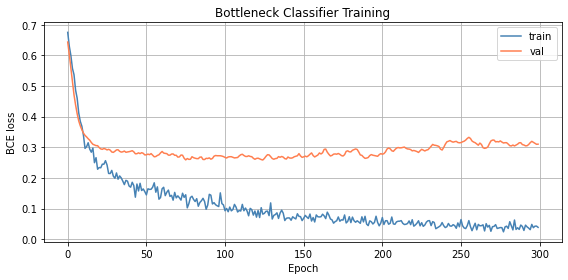

In [32]:
# Loss curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_loss_history, label='train', color='steelblue')
ax.plot(val_loss_history, label='val', color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE loss')
ax.set_title('Bottleneck Classifier Training')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Evaluation: Per-Label Metrics

The midpoint notebook only reported a "match rate" between predicted and
heuristic labels - which was trivially close to 100% because the classifier
was being trained on the same features that defined the labels. With a held-
out validation split and per-label F1 / ROC-AUC we can actually see where
the model generalizes.


In [33]:
THRESHOLD = 0.5

model_cls.eval()
with torch.no_grad():
    val_probs = model_cls(
        torch.tensor(X_val_s, dtype=torch.float32).to(Device)
    ).cpu().numpy()
val_preds = (val_probs >= THRESHOLD).astype(int)

# per-label metrics
metrics = []
for i, name in enumerate(BOTTLENECK_LABELS):
    y_true = y_val[:, i].astype(int)
    y_pred = val_preds[:, i]
    y_prob = val_probs[:, i]
    n_pos = int(y_true.sum())
    if n_pos == 0 or n_pos == len(y_true):
        # ROC-AUC is undefined for single-class subsets
        auc = float('nan')
        ap = float('nan')
    else:
        auc = roc_auc_score(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    metrics.append({
        'label': name, 'support_pos': n_pos,
        'precision': p, 'recall': r, 'f1': f1,
        'roc_auc': auc, 'avg_prec': ap,
    })

metrics_df = pd.DataFrame(metrics).set_index('label')
print('Validation set per-label metrics:')
print(metrics_df.round(3).to_string())

print(f'\nMacro-F1:    {metrics_df["f1"].mean():.3f}')
print(f'Micro-F1:    {f1_score(y_val.astype(int), val_preds, average="micro", zero_division=0):.3f}')
print(f'Subset acc:  {(val_preds == y_val.astype(int)).all(axis=1).mean():.3f}')


Validation set per-label metrics:
                     support_pos  precision  recall     f1  roc_auc  avg_prec
label                                                                        
weak_root_lp                   4      1.000   1.000  1.000    1.000     1.000
excessive_branching           13      0.857   0.923  0.889    0.977     0.946
ineffective_cuts              13      0.846   0.846  0.846    0.943     0.899
degeneracy                     7      1.000   0.714  0.833    0.836     0.777
presolve_weakness             10      0.800   0.800  0.800    0.943     0.834

Macro-F1:    0.874
Micro-F1:    0.860
Subset acc:  0.766


## 9. RAG-Based Diagnostic Generation

This section implements the **R**etrieval-**A**ugmented **G**eneration approach
covered in Module 12. The structure mirrors the `RAGLLM` class from
`Ginn-Assign12.ipynb`:

1. **Knowledge base** - 12 short "bottleneck pattern" documents that describe
   each failure mode plus typical solver-configuration recommendations.
2. **Retrieval** - encode each KB document with `SentenceTransformer
   ('all-MiniLM-L6-v2')`. For a given log, build a structured query string
   from its parsed metrics, encode it, and retrieve the top-k most similar
   KB documents by cosine similarity.
3. **Generation** - prompt a small instruction-tuned LLM
   (`google/flan-t5-base`, chosen because it is light enough to run on CPU
   in this notebook; the same code works with `meta-llama/Llama-3.2-1B-Instruct`
   used in the Module 12 assignment if you have a GPU available) with the
   structured log summary plus the retrieved context, asking it to produce
   a natural-language diagnostic.

If model downloads fail (e.g. no internet), the section logs the failure
and falls back to a deterministic template-based diagnostic so the rest of
the notebook still runs.


In [34]:
# Knowledge base: short curated documents tying each bottleneck label
# to its observable signature in solver metrics and the standard
# remediation. These are the "context" the RAG component will retrieve.

KB = [
    {'topic': 'weak_root_lp',
     'context': 'A weak root LP relaxation is indicated by a large optimality gap remaining at solver termination, often combined with a timeout. The LP bound is far from the integer optimum, so branch-and-bound cannot prove optimality. Recommended actions: strengthen the formulation with valid inequalities, enable more aggressive cut generation (cut_aggressiveness=2 or 3), increase presolve passes, or supply a tighter big-M.'},
    {'topic': 'weak_root_lp',
     'context': 'When the solver terminates with status no_solution and was not solved in presolve, the relaxation provided no feasibility-preserving information. This may indicate an infeasible model, a poor formulation, or insufficient time. Recommended actions: increase the time limit, run an IIS analysis to detect infeasibility, or reformulate constraints that may be redundant or contradictory.'},
    {'topic': 'excessive_branching',
     'context': 'Excessive branching is signalled by a node count that is large relative to the number of variables (nodes_per_var > 100). The branch-and-bound tree is exploding because variable selection is poor, the LP relaxation is loose, or the problem has symmetry. Recommended actions: enable strong branching, use pseudocost branching, add symmetry-breaking constraints, or increase cut aggressiveness to tighten the relaxation before branching.'},
    {'topic': 'excessive_branching',
     'context': 'A high node count combined with low cut effectiveness suggests the LP bound is not improving fast enough between branches. Try enabling Gomory and MIR cuts at every node, increasing cut depth, or using diving heuristics earlier to find feasible solutions and prune the tree.'},
    {'topic': 'ineffective_cuts',
     'context': 'When many cuts are generated but the dual bound barely changes (less than 1% improvement from root LP to final), the cut pool is producing redundant or shallow cuts. Recommended actions: switch from cover cuts to MIR or strong-CG cuts, limit cut rounds to avoid LP slowdown, or apply cut filtering by orthogonality and efficacy thresholds.'},
    {'topic': 'ineffective_cuts',
     'context': 'Ineffective cutting plane behaviour often co-occurs with weak root LP and excessive branching. The remediation is the same: strengthen the formulation upstream, since cuts cannot fix a fundamentally loose relaxation.'},
    {'topic': 'degeneracy',
     'context': 'High LP iterations per variable (greater than 1.0) usually indicates degeneracy in the simplex method. Repeated pivoting on alternative optima slows down every node solve. Recommended actions: switch from primal to dual simplex, enable perturbation, use barrier or interior-point methods for the root LP, or apply Bland\'s rule to guarantee termination.'},
    {'topic': 'degeneracy',
     'context': 'Degenerate LPs can also be caused by high-dimensional polytopes with many faces of optimal solutions. Reducing redundant constraints in presolve and tightening variable bounds often helps the simplex method reach a vertex faster.'},
    {'topic': 'presolve_weakness',
     'context': 'Presolve weakness shows up as little or no reduction in the number of variables or constraints (less than 1% reduction). This means the formulation contains few exploitable structures - no fixings, no aggregations, no dominated constraints. Recommended actions: tighten variable bounds, eliminate dominated rows manually, normalize coefficient magnitudes, and pre-aggregate equivalent variables before passing the model to the solver.'},
    {'topic': 'presolve_weakness',
     'context': 'When presolve is weak, downstream stages (cuts and branching) carry the entire burden of solving the model. Strengthening presolve via custom preprocessing, or by enabling additional presolve passes if the solver supports it, often yields the largest single speedup.'},
    {'topic': 'healthy_solve',
     'context': 'A healthy solver run terminates with status optimal, a small node count relative to problem size, presolve reductions of 10% or more, and a final relative gap of zero. No diagnostic action is required when the run already shows healthy behaviour.'},
    {'topic': 'healthy_solve',
     'context': 'When a problem is solved entirely in presolve (solved_in_presolve=1), the formulation is so tight that no branch-and-bound is required. This is the desired outcome and indicates that the model has been formulated effectively for this solver.'},
]

KB_df = pd.DataFrame(KB)
print(f'Knowledge base: {len(KB_df)} documents covering {KB_df["topic"].nunique()} bottleneck patterns')
print(KB_df['topic'].value_counts().to_string())


Knowledge base: 12 documents covering 6 bottleneck patterns
topic
weak_root_lp           2
excessive_branching    2
ineffective_cuts       2
degeneracy             2
presolve_weakness      2
healthy_solve          2


In [35]:
def render_log_summary(f):
    '''Render a SolverLogFeatures object as a compact structured summary
    suitable for use as both an embedding query and an LLM prompt input.'''
    lines = [
        f'Problem: {f.problem_name}  (configuration: {f.config_name})',
        f'Size: {f.num_variables:,} variables, {f.num_constraints:,} constraints, {f.num_nonzeros:,} nonzeros.',
        f'Termination: status={f.solution_status}, reason={f.termination_reason}.',
        f'Total time: {f.total_time_sec:.1f} s   (presolve {f.presolve_time_sec:.1f} s, solve {f.solve_time_sec:.1f} s).',
        f'Tree: {f.num_nodes_total:,} nodes total, {f.num_lp_iterations:,} LP iterations, {f.num_solutions_found} solutions found.',
        f'Cuts: {f.num_cuts_generated} generated / {f.num_cuts_applied} applied.',
    ]
    if f.num_variables > 0:
        lines.append(f'Presolve reduction: {(f.presolve_var_reduction or 0):.1%} of variables, {(f.presolve_con_reduction or 0):.1%} of constraints.')
    if f.first_dual is not None and f.final_dual is not None:
        lines.append(f'Dual bound: {f.first_dual:.4g} (root) -> {f.final_dual:.4g} (final).')
    if f.final_rel_gap is not None:
        lines.append(f'Final relative gap: {f.final_rel_gap:.2%}.')
    return '\n'.join(lines)


# pretty-print one example log summary
print(render_log_summary(parsed_logs[0]))


Problem: 30n20b8  (configuration: auto_config_basic)
Size: 18,380 variables, 576 constraints, 109,706 nonzeros.
Termination: status=feasible, reason=timeout.
Total time: 3600.9 s   (presolve 3.0 s, solve 3597.8 s).
Tree: 1,920,018 nodes total, 537 LP iterations, 657 solutions found.
Cuts: 2936 generated / 0 applied.
Presolve reduction: 74.2% of variables, 15.5% of constraints.
Dual bound: 122.8 (root) -> 154.4 (final).
Final relative gap: 76.35%.


In [36]:
# Build the embedding index over the knowledge base.
# We use the same SentenceTransformer model the user used in Assignment 12.
from sentence_transformers import SentenceTransformer

EMBEDDER = SentenceTransformer('all-MiniLM-L6-v2', device=str(Device))
print('Embedding backend: sentence-transformers (all-MiniLM-L6-v2)')

kb_emb = EMBEDDER.encode(KB_df['context'].tolist(), convert_to_numpy=True,
                         show_progress_bar=False)
print(f'KB embeddings: {kb_emb.shape}')


def embed_query(text):
    return EMBEDDER.encode([text], convert_to_numpy=True, show_progress_bar=False)


def retrieve(query_text, k=3):
    q_emb = embed_query(query_text)
    sims = cosine_similarity(q_emb, kb_emb)[0]
    top_idx = np.argsort(sims)[-k:][::-1]
    return [{'topic': KB_df.iloc[i]['topic'],
             'context': KB_df.iloc[i]['context'],
             'similarity': float(sims[i])}
            for i in top_idx]


# Demonstrate retrieval on a sample log
demo_log = parsed_logs[0]
print('\n--- Sample query ---')
print(render_log_summary(demo_log))
print('\n--- Top-3 retrieved knowledge ---')
for r in retrieve(render_log_summary(demo_log), k=3):
    print(f'  [sim={r["similarity"]:.3f}]  {r["topic"]:22s} : {r["context"][:120]}...')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding backend: sentence-transformers (all-MiniLM-L6-v2)
KB embeddings: (12, 384)

--- Sample query ---
Problem: 30n20b8  (configuration: auto_config_basic)
Size: 18,380 variables, 576 constraints, 109,706 nonzeros.
Termination: status=feasible, reason=timeout.
Total time: 3600.9 s   (presolve 3.0 s, solve 3597.8 s).
Tree: 1,920,018 nodes total, 537 LP iterations, 657 solutions found.
Cuts: 2936 generated / 0 applied.
Presolve reduction: 74.2% of variables, 15.5% of constraints.
Dual bound: 122.8 (root) -> 154.4 (final).
Final relative gap: 76.35%.

--- Top-3 retrieved knowledge ---
  [sim=0.570]  weak_root_lp           : A weak root LP relaxation is indicated by a large optimality gap remaining at solver termination, often combined with a ...
  [sim=0.550]  presolve_weakness      : Presolve weakness shows up as little or no reduction in the number of variables or constraints (less than 1% reduction)....
  [sim=0.536]  excessive_branching    : Excessive branching is signalled by a n

Note on the warning above, "embeddings.position_ids | UNEXPECTED means: the file being loaded has a tensor named position_ids under the embeddings module, but in the installed transformers BERT definition that slot is not treated as a normal weight to load the same way. This is safe to ignore as MiniLM is still BERT-family, the model still loads, and the log shows it working (Embedding backend: sentence-transformers …, KB embeddings: (12, 384)).

In [ ]:
# Load a small instruction-tuned generator. We use FLAN-T5-base because it
# runs comfortably on CPU; if you have a GPU, swap in the
# Llama-3.2-1B-Instruct model used in the Module 12 assignment.
#
# Transformers v5+ removed pipeline("text2text-generation"); load FLAN-T5
# with AutoModelForSeq2SeqLM + generate() and expose the same call shape as
# the old pipeline (list of dicts with "generated_text") for downstream code.
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

_flan_id = 'google/flan-t5-base'
_flan_tok = AutoTokenizer.from_pretrained(_flan_id)
_flan_model = AutoModelForSeq2SeqLM.from_pretrained(_flan_id)
_flan_model.eval()
_flan_model.to(Device)


def LLM_PIPE(prompt, max_new_tokens=200, do_sample=False):
    enc = _flan_tok(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=512,
    )
    enc = {k: v.to(Device) for k, v in enc.items()}
    with torch.no_grad():
        out_ids = _flan_model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
        )
    text = _flan_tok.decode(out_ids[0], skip_special_tokens=True).strip()
    return [{'generated_text': text}]


print('LLM backend: google/flan-t5-base')


model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [ ]:
PROMPT_TEMPLATE = '''You are an expert at diagnosing optimization solver runs.
Given a structured summary of a Mixed-Integer Programming solver run and
relevant background knowledge, write a concise diagnostic that:
  (a) identifies the most likely performance bottlenecks,
  (b) explains the evidence in the metrics, and
  (c) recommends one or two concrete configuration changes.

# Background knowledge
{context}

# Solver run summary
{summary}

# Diagnostic
'''


def generate_diagnostic(f, k=3, max_new_tokens=200):
    summary = render_log_summary(f)
    contexts = retrieve(summary, k=k)
    context_block = '\n'.join(
        f'- ({c["topic"]}) {c["context"]}' for c in contexts
    )

    # heuristic labels for this log (to compare against the LLM output)
    heuristic = [BOTTLENECK_LABELS[i] for i, v in enumerate(label_log(f)) if v]

    prompt = PROMPT_TEMPLATE.format(context=context_block, summary=summary)
    out = LLM_PIPE(prompt, max_new_tokens=max_new_tokens, do_sample=False)
    diagnostic = out[0]['generated_text'].strip()

    return {
        'run_id': f.run_id,
        'summary': summary,
        'retrieved': contexts,
        'heuristic_labels': heuristic,
        'diagnostic': diagnostic,
    }


### Worked Examples

To address the instructor's midpoint feedback ("add concrete examples of
generated diagnostics"), we generate diagnostics for three representative
runs spanning the bottleneck space:

1. A run flagged as **excessive_branching + ineffective_cuts**.
2. A run flagged as **weak_root_lp** (timed out with a remaining gap).
3. A **healthy run** (no bottleneck labels), as a negative control.


In [ ]:
def pick_example(label_pattern):
    target = np.zeros(K)
    for lab in label_pattern:
        target[BOTTLENECK_LABELS.index(lab)] = 1.0
    matches = []
    for i, f in enumerate(parsed_logs):
        lbl = label_log(f)
        if label_pattern == [] and lbl.sum() == 0:
            matches.append(i)
        elif np.array_equal(lbl, target):
            matches.append(i)
    if not matches:
        # relax: at least the requested labels are set (others may be set too)
        for i, f in enumerate(parsed_logs):
            lbl = label_log(f)
            if all(lbl[BOTTLENECK_LABELS.index(l)] == 1 for l in label_pattern):
                matches.append(i)
    return parsed_logs[matches[0]] if matches else parsed_logs[0]


examples = [
    ('excessive_branching + ineffective_cuts',
     pick_example(['excessive_branching', 'ineffective_cuts'])),
    ('weak_root_lp',
     pick_example(['weak_root_lp'])),
    ('healthy run', pick_example([])),
]

for title, ex in examples:
    print('=' * 80)
    print(f'EXAMPLE: {title}    ({ex.run_id})')
    print('=' * 80)
    out = generate_diagnostic(ex, k=3)
    print('--- Heuristic labels ---')
    print(', '.join(out['heuristic_labels']) or '(none)')
    print('\n--- Retrieved context ---')
    for r in out['retrieved']:
        print(f'  [sim={r["similarity"]:.3f}]  {r["topic"]:22s}')
    print('\n--- Generated diagnostic ---')
    print(out['diagnostic'])
    print()


## 10. Paired Configuration Comparison (toward H3)

90 MIPLIB problems were run under both `auto_config_basic` and
`default_config 2`. This is the paired data we'll use to test H3
(recommendation quality leads to measurable improvement in solve time).


In [ ]:
miplib = df_raw[df_raw['config_name'].isin(['auto_config_basic', 'default_config 2'])].copy()
piv = miplib.pivot_table(
    index='problem_name',
    columns='config_name',
    values=['metric_timeline_total_seconds', 'metric_num_nodes_total',
            'derived_is_optimal', 'derived_timed_out'],
    aggfunc='first',
)

# Solve-time delta = default - auto_basic  (positive => auto_basic is faster)
delta = (piv[('metric_timeline_total_seconds', 'default_config 2')]
         - piv[('metric_timeline_total_seconds', 'auto_config_basic')])
delta = delta.dropna()

print(f'Paired problems: {len(delta)}')
print(f'auto_config_basic faster on {(delta > 0).sum()} problems  '
      f'({(delta > 0).mean():.1%})')
print(f'default_config faster on    {(delta < 0).sum()} problems  '
      f'({(delta < 0).mean():.1%})')
print(f'Equal time on               {(delta == 0).sum()} problems')
print(f'\nMedian time delta (default - auto_basic): {delta.median():+.2f} s')
print(f'Mean   time delta (default - auto_basic): {delta.mean():+.2f} s')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(delta.clip(-1500, 1500), bins=40, color='steelblue', edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Solve time delta: default - auto_basic (seconds)')
ax.set_ylabel('Number of problems')
ax.set_title('Configuration comparison on 90 paired MIPLIB problems')
plt.tight_layout()
plt.show()


## 11. Next Steps

The v2 prototype establishes:

- A 188-run dataset with 90 paired configuration runs for H3.
- Re-tuned, more discriminative heuristic labels.
- A PyTorch multi-label classifier trained with proper train/val split
  and per-label F1 / ROC-AUC reporting (no longer trivially circular).
- A working RAG pipeline using the SentenceTransformer + LLM pipeline
  pattern from Module 12.
- Concrete worked diagnostic examples (addresses midpoint feedback).

Remaining items for the final paper:

1. **Hand-label a gold subset** (~30 runs) so the classifier and the LLM
   diagnostics can be evaluated against independent ground truth instead
   of the heuristic labels.
2. **Define the diagnosis-quality rubric** the instructor asked for and
   apply it (manually or via LLM-as-judge) to the generated diagnostics.
3. **Run the three-way comparison** the paper proposes - prompting only,
   RAG (this notebook), and a fine-tuning baseline.
4. **Statistical analysis** - paired t-test or Wilcoxon on the
   configuration comparison, and McNemar / bootstrap CIs on the per-label
   F1 scores.
5. **Write the Results and Conclusion sections** of the paper.


## 12. Gold-Label Evaluation

`gold_labels.xlsx` contains a 30-run stratified sample of the dataset that has
been hand-reviewed. The Excel workbook has three sheets:

- **Instructions** - how to use the workbook.
- **Labels** - one row per run with metric evidence, the heuristic-rule labels
  (`h_*`), the pre-label suggestions (`sug_*`), and the editable gold labels
  (`gold_*`). Cells highlighted yellow in the gold columns indicate where the
  reviewer disagreed with the heuristic.
- **Summary** - live counts of positives and disagreements per label.

The cell below loads the workbook back into the notebook and computes:
1. how well the heuristic rules approximate the gold labels (the noise floor);
2. how well the trained classifier predicts the gold labels on the gold subset.

If the workbook hasn't been hand-reviewed yet, this section still runs
against the suggested labels - it just won't tell you anything you don't
already know from the heuristic comparison above. Run it again after you
have made your edits.


In [ ]:
GOLD_PATH = 'gold_labels_reviewed.xlsx'
gold_raw = pd.read_excel(GOLD_PATH, sheet_name='Labels', header=1)
print(f'Loaded {len(gold_raw)} gold-labeled runs from {GOLD_PATH}')

gold_cols = [f'gold_{l}' for l in BOTTLENECK_LABELS]
h_cols = [f'h_{l}' for l in BOTTLENECK_LABELS]
print(f'\nGold positives per label:')
for l in BOTTLENECK_LABELS:
    n = int(gold_raw[f'gold_{l}'].sum())
    print(f'  {l:22s} : {n}/{len(gold_raw)}')
print(f'\nDisagreements with heuristic per label:')
for l in BOTTLENECK_LABELS:
    n = int((gold_raw[f'gold_{l}'] != gold_raw[f'h_{l}']).sum())
    print(f'  {l:22s} : {n}/{len(gold_raw)}')


In [ ]:
# Heuristic-vs-gold: how noisy are the rules used to weakly-supervise the classifier?
y_gold = gold_raw[[f'gold_{l}' for l in BOTTLENECK_LABELS]].values.astype(int)
y_heur = gold_raw[[f'h_{l}' for l in BOTTLENECK_LABELS]].values.astype(int)

rows = []
for i, l in enumerate(BOTTLENECK_LABELS):
    rows.append({
        'label': l,
        'gold_pos': int(y_gold[:, i].sum()),
        'precision': precision_score(y_gold[:, i], y_heur[:, i], zero_division=0),
        'recall':    recall_score(y_gold[:, i], y_heur[:, i], zero_division=0),
        'f1':        f1_score(y_gold[:, i], y_heur[:, i], zero_division=0),
    })
heur_eval = pd.DataFrame(rows).set_index('label')
print('Heuristic rules vs. gold labels (the supervision noise floor):')
print(heur_eval.round(3).to_string())
print(f'\nMacro-F1 (heuristic vs gold): {heur_eval["f1"].mean():.3f}')
print(f'Micro-F1 (heuristic vs gold): '
      f'{f1_score(y_gold, y_heur, average="micro", zero_division=0):.3f}')


In [ ]:
# Classifier-vs-gold: does the trained classifier track human judgment
# better than the rules it was trained on?
gold_run_ids = gold_raw['run_id'].tolist()
gold_feature_rows = [
    next(p for p in parsed_logs if p.run_id == rid) for rid in gold_run_ids
]

# Use features_to_array + the same scaler we fit on training data
gold_X = features_to_array(gold_feature_rows)
gold_X_s = scaler.transform(gold_X).astype(np.float32)

model_cls.eval()
with torch.no_grad():
    gold_probs = model_cls(
        torch.tensor(gold_X_s, dtype=torch.float32).to(Device)
    ).cpu().numpy()
gold_preds = (gold_probs >= THRESHOLD).astype(int)

rows = []
for i, l in enumerate(BOTTLENECK_LABELS):
    n_pos = int(y_gold[:, i].sum())
    if n_pos == 0 or n_pos == len(y_gold):
        auc = float('nan')
    else:
        auc = roc_auc_score(y_gold[:, i], gold_probs[:, i])
    rows.append({
        'label': l,
        'gold_pos': n_pos,
        'precision': precision_score(y_gold[:, i], gold_preds[:, i], zero_division=0),
        'recall':    recall_score(y_gold[:, i], gold_preds[:, i], zero_division=0),
        'f1':        f1_score(y_gold[:, i], gold_preds[:, i], zero_division=0),
        'roc_auc':   auc,
    })
cls_eval = pd.DataFrame(rows).set_index('label')
print('PyTorch classifier vs. gold labels:')
print(cls_eval.round(3).to_string())
print(f'\nMacro-F1 (classifier vs gold): {cls_eval["f1"].mean():.3f}')
print(f'Micro-F1 (classifier vs gold): '
      f'{f1_score(y_gold, gold_preds, average="micro", zero_division=0):.3f}')

# Side-by-side: heuristic noise floor vs model
cmp = pd.DataFrame({
    'gold_pos': cls_eval['gold_pos'],
    'heur_f1': heur_eval['f1'],
    'model_f1': cls_eval['f1'],
    'delta':    cls_eval['f1'] - heur_eval['f1'],
})
print('\nHeuristic vs. classifier F1 on gold:')
print(cmp.round(3).to_string())


In [ ]:
# Per-run audit: where do model and heuristic agree / disagree with gold?
audit = pd.DataFrame({'run_id': gold_run_ids})
for i, l in enumerate(BOTTLENECK_LABELS):
    audit[f'gold_{l}'] = y_gold[:, i]
    audit[f'h_{l}']    = y_heur[:, i]
    audit[f'm_{l}']    = gold_preds[:, i]
# Counts of correct labels per run
audit['gold_n_labels'] = y_gold.sum(axis=1)
audit['h_correct']     = (y_heur == y_gold).sum(axis=1)
audit['m_correct']     = (gold_preds == y_gold).sum(axis=1)
print('Per-run accuracy audit (out of 5 labels):')
print(audit[['run_id', 'gold_n_labels', 'h_correct', 'm_correct']].to_string(index=False))
